In [ ]:
from google.colab import files
uploaded = files.upload()

Saving survey lung cancer.csv to survey lung cancer.csv


In [ ]:
import pandas as pd

df = pd.read_csv('survey lung cancer.csv')

print("Dataset loaded")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
df.head()

Dataset loaded
Rows    : 309
Columns : 16


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
# How many rows and columns?
print("Shape:", df.shape)

# Any missing values?
print("\nMissing values:\n", df.isnull().sum())

# What does the data look like?
print("\nFirst look:")
df.head()

Shape: (309, 16)

Missing values:
 GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

First look:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
# How many YES vs NO?
print(df['LUNG_CANCER'].value_counts())

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


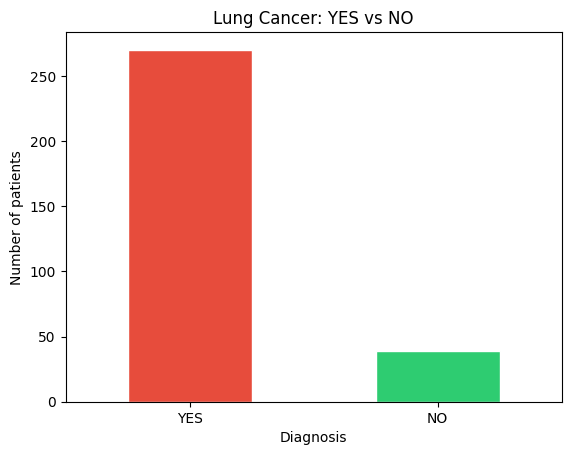

In [ ]:
import matplotlib.pyplot as plt

df['LUNG_CANCER'].value_counts().plot(kind='bar',
    color=['#e74c3c', '#2ecc71'], edgecolor='white')

plt.title('Lung Cancer: YES vs NO')
plt.xlabel('Diagnosis')
plt.ylabel('Number of patients')
plt.xticks(rotation=0)
plt.show()

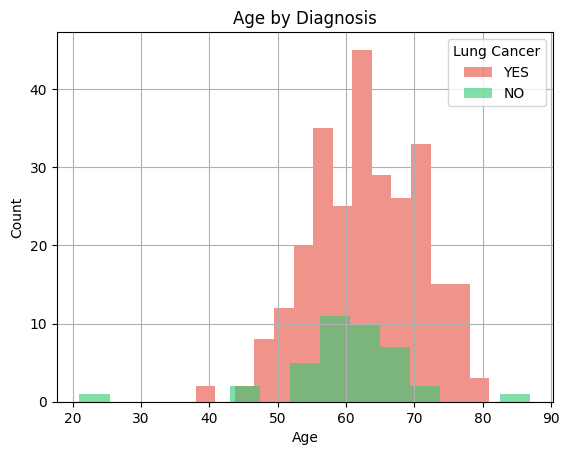

In [ ]:
# Do older patients get cancer more?
for label, color in zip(['YES', 'NO'], ['#e74c3c', '#2ecc71']):
    df[df['LUNG_CANCER'] == label]['AGE'].hist(
        bins=15, alpha=0.6, color=color, label=label)

plt.title('Age by Diagnosis')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Lung Cancer')
plt.show()

In [ ]:
# Some column names have hidden spaces — this fixes that
df.columns = df.columns.str.strip()

print("Column names:")
print(df.columns.tolist())

Column names:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# GENDER: M → 1, F → 0
df['GENDER'] = LabelEncoder().fit_transform(df['GENDER'])

# LUNG_CANCER: YES → 1, NO → 0
df['LUNG_CANCER'] = LabelEncoder().fit_transform(df['LUNG_CANCER'])

print("After encoding:")
print(df[['GENDER', 'LUNG_CANCER']].value_counts())
df.head()

After encoding:
GENDER  LUNG_CANCER
1       1              145
0       1              125
        0               22
1       0               17
Name: count, dtype: int64


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [ ]:
# X = everything the model learns FROM (symptoms)
# y = what the model tries to PREDICT (cancer yes/no)

X = df.drop('LUNG_CANCER', axis=1)   # all columns except target
y = df['LUNG_CANCER']                # only the target column

print("X shape (features):", X.shape)
print("y shape (target)  :", y.shape)

X shape (features): (309, 15)
y shape (target)  : (309,)


In [ ]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))

Training samples: 247
Testing  samples: 62


In [ ]:
from sklearn.preprocessing import StandardScaler

# Makes all numbers on the same scale
# Fit ONLY on training data — then apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [ ]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train it — this is where the "learning" happens
lr_model.fit(X_train, y_train)

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [ ]:
# Train the random forest
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it
rf_model.fit(X_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [ ]:
# Install if needed (Colab usually has it)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
import numpy as np

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE :", dict(zip(*np.unique(y_train_bal, return_counts=True))))
# Should show equal counts like {0: 216, 1: 216}

Before SMOTE: {np.int64(0): np.int64(31), np.int64(1): np.int64(216)}
After SMOTE : {np.int64(0): np.int64(216), np.int64(1): np.int64(216)}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced.fit(X_train_bal, y_train_bal)

print("Balanced Random Forest trained!")

Balanced Random Forest trained!


In [ ]:
# Check accuracy of both models
from sklearn.metrics import accuracy_score

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy      :", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9032258064516129
Random Forest Accuracy      : 0.9193548387096774


In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=['No Cancer', 'Cancer']))

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['No Cancer', 'Cancer']))

=== Logistic Regression ===
              precision    recall  f1-score   support

   No Cancer       0.62      0.62      0.62         8
      Cancer       0.94      0.94      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.78      0.78        62
weighted avg       0.90      0.90      0.90        62

=== Random Forest ===
              precision    recall  f1-score   support

   No Cancer       0.67      0.75      0.71         8
      Cancer       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62



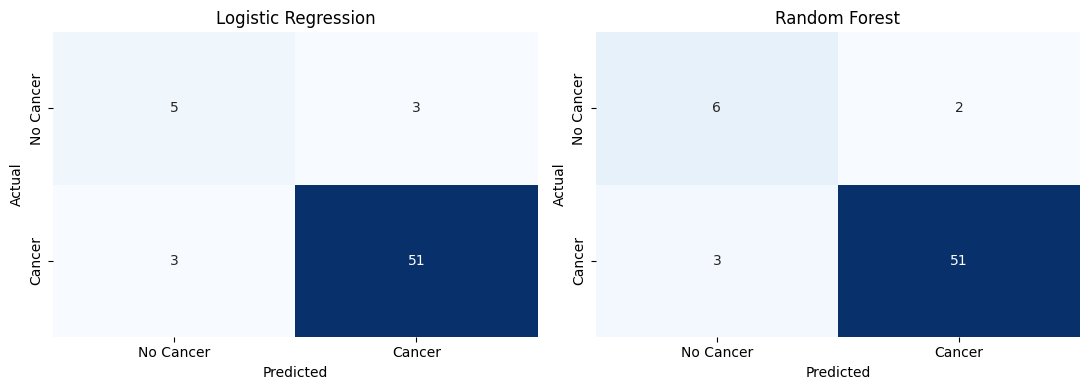

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, pred in zip(axes,
    ['Logistic Regression', 'Random Forest'],
    [lr_pred, rf_pred]):

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Cancer', 'Cancer'],
                yticklabels=['No Cancer', 'Cancer'],
                cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

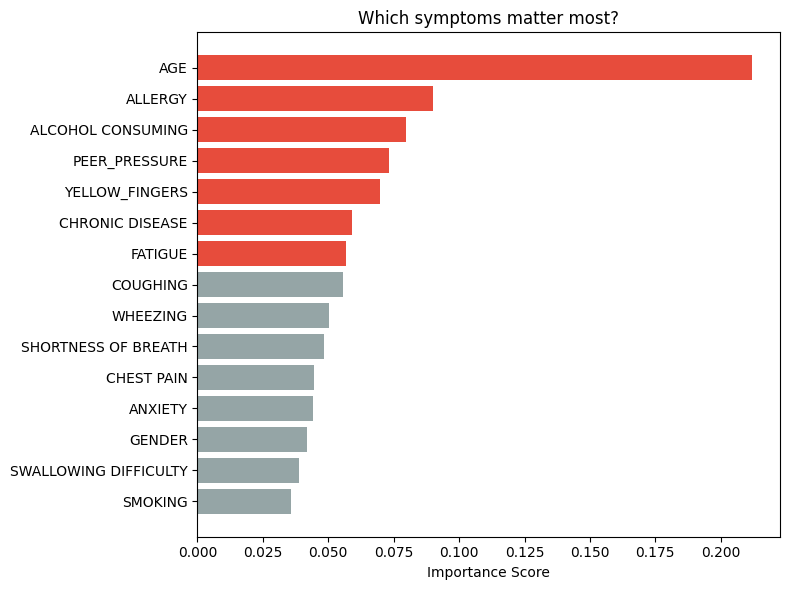

In [ ]:
import pandas as pd

feature_names = df.drop('LUNG_CANCER', axis=1).columns
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=['#e74c3c' if v > feat_df['Importance'].median()
                else '#95a5a6' for v in feat_df['Importance']])
plt.xlabel('Importance Score')
plt.title('Which symptoms matter most?')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(rf_balanced, 'model.pkl')   # ← NEW balanced model ✅
joblib.dump(scaler, 'scaler.pkl')

print("Balanced model saved!")

NameError: name 'joblib' is not defined

In [ ]:
from google.colab import files

files.download('model.pkl')
files.download('scaler.pkl')